In [848]:
#Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [849]:
#Load Dataset

df = pd.read_csv('DataSets/used_cars.csv')

In [850]:
#Read first 5 Rows
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [851]:
#Read Last 5 rows
df.tail()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


In [852]:
#Read Sample Random Data
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2893,Mercedes-Benz,S-Class S 63 AMG,2015,"79,876 mi.",Gasoline,577.0HP 5.5L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,White,None reported,Yes,"$45,750"
3669,Chevrolet,Silverado 1500 Base,1999,"88,750 mi.",Gasoline,255.0HP 4.8L 8 Cylinder Engine Gasoline Fuel,A/T,White,Gray,None reported,Yes,"$6,800"
1158,BMW,M5 Competition,2020,"35,400 mi.",Gasoline,617.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,8-Speed A/T,Orange,Black,None reported,Yes,"$71,950"
867,BMW,X5 eDrive xDrive40e,2018,"45,090 mi.",Plug-In Hybrid,313.0HP 2.0L 4 Cylinder Engine Plug-In Electri...,8-Speed A/T,Gray,Black,At least 1 accident or damage reported,Yes,"$30,750"
289,Volkswagen,Golf R 4-Door w/DCC & Navigation,2018,"36,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,"$32,000"


In [853]:
# Check the shape of data means checking the number of rows and cols
df.shape

(4009, 12)

In [854]:
#Check the full information of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [855]:
#Check the basic stats of dataset (only of numeric rows)
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [856]:
# Check the null values in every column using .isna(), Since it returns an object so we use .isna().sum() -> 
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [857]:
df.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

# Observations(Till now):

- We have total 4009 rows and 12 columns --> 11 input features and one `price` feature we have to predict.
- We have only one column as integer i.e. `model_year` , means we have to extract the numerical data from columns and convert some to integers like `price` and `milage`.
- There are null values in columns -> `fuel_type` -> `170` , `accident` -> `113` , `clean_title` -> `596` which needed to be handled carefully.

In [858]:
#Creating a copy of dataset to prevent any blunder in the original one.
df_copy = df.copy()

#Data Cleaning
In this step, We will:
- Handles the missing values
- Extract the numeric info from `price` ,`milage` and other columns if any.
- check for duplicates

In [859]:
#Check for duplicate data points in the Dataset.
df_copy.duplicated().sum()

np.int64(0)

We have Zero Duplicate Value

In [860]:
# Now handling the missing data of fuel_type.
df_copy['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [861]:
#We can  convert `-` and `not supported` to `NaN` and then fill the null values to mode of the data so as to make the data or fuel_type column more balanced.
df_copy['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], np.nan)

In [862]:
#Now filling the fuel_type column with mode.
df_copy['fuel_type'] = df_copy['fuel_type'].fillna(value=df_copy['fuel_type'].mode()[0]) # mode()[0] means the frequent one.

In [863]:
#Lets verify
df_copy['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3526
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [864]:
#Now Lets handle accident
df_copy['accident'].value_counts(dropna=False)

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [865]:
#We can convert the NaN values to None reported only. We can simply use fillna() function...
df_copy['accident'] = df_copy['accident'].fillna(value='None reported')

In [866]:
#Verify.....
df_copy['accident'].value_counts(dropna=False)

accident
None reported                             3023
At least 1 accident or damage reported     986
Name: count, dtype: int64

In [867]:
#Now Handle the clean_title..
df['clean_title'].value_counts(dropna=False)

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

In [868]:
#We cannot simply say NaN --> No, there may be a chance of NaN->Yes. So, for now let's convert it into Unknown
df_copy['clean_title'] = df_copy['clean_title'].fillna(value='Unknown')

In [869]:
#verifying.....
df_copy['clean_title'].value_counts(dropna=False)

clean_title
Yes        3413
Unknown     596
Name: count, dtype: int64

#Now let's fetch the numeric data from milage and price

In [870]:
#check the sample
df_copy[['price' , 'milage']].head()

,price,milage
0,"$10,300","51,000 mi."
1,"$38,005","34,742 mi."
2,"$54,598","22,372 mi."
3,"$15,500","88,900 mi."
4,"$34,999","9,835 mi."


In [871]:
#Checl their datatype
df_copy[['price' , 'milage']].dtypes

price     str
milage    str
dtype: object

In [872]:
#removing `$` from `Price` and mi from `milage`

df_copy['price'] = df_copy['price'].str.replace('$' , '' , regex=False).str.replace(',' , '' , regex=False).astype(float)
df_copy['milage'] = df['milage'].str.replace('mi.' , '' ).str.replace(',','').astype(float)
df_copy.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0


In [873]:
#Check the unique values of each column
df_copy.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          5
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        2
price           1569
dtype: int64

In [874]:
# Check data types
df_copy.dtypes

brand               str
model               str
model_year        int64
milage          float64
fuel_type           str
engine              str
transmission        str
ext_col             str
int_col             str
accident            str
clean_title         str
price           float64
dtype: object

In [875]:
#Let's check the values count of categorical columns
categorical_cols = [
    'brand',
    'fuel_type',
    'engine',
    'transmission',
    'ext_col',
    'int_col',
    'accident',
    'clean_title'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_copy[col].value_counts().head(15))


brand:
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Name: count, dtype: int64

fuel_type:
fuel_type
Gasoline          3526
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

engine:
engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel             42
285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel            40
5.7L V8 16V MPFI OHV                          

We have `-` in our `engine` , `int_col` and `ext_col`. We need to handle them also

In [876]:
for col in ['engine' , 'ext_col' , 'int_col']:
    print(f"{col} : {(df_copy[col] == '–').sum()}")

engine : 45
ext_col : 15
int_col : 133


In [877]:
#Replace them with Unknown
for col in ['engine' , 'ext_col' , 'int_col']:
    df_copy[col] = df_copy[col].replace('–','Unknown')

In [878]:
#Verify...
for col in ['engine' , 'ext_col' , 'int_col']:
    print(f"{col} : {(df_copy[col] == '–').sum()}")

engine : 0
ext_col : 0
int_col : 0


# EDA (Exploratory Data Analysis)
- In this we'll see the relationship between columns

In [879]:
#Again checking the basic stats....
df_copy.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


#The model_year ranges from 1974 - 2024. So we can calculate the Age of each model in the feature engineering step.

<Axes: xlabel='model_year', ylabel='Count'>

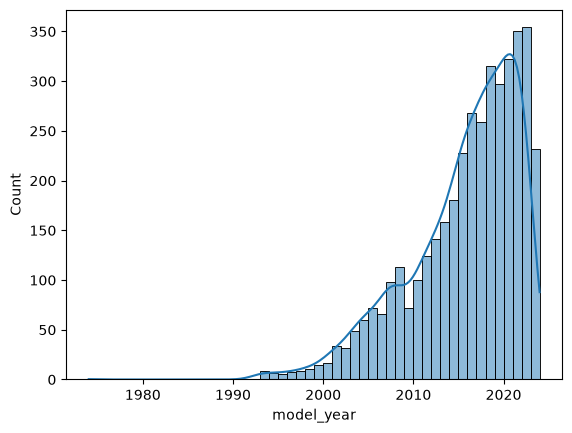

In [880]:
sns.histplot(df_copy['model_year'] , kde=True)

<Axes: xlabel='price', ylabel='Count'>

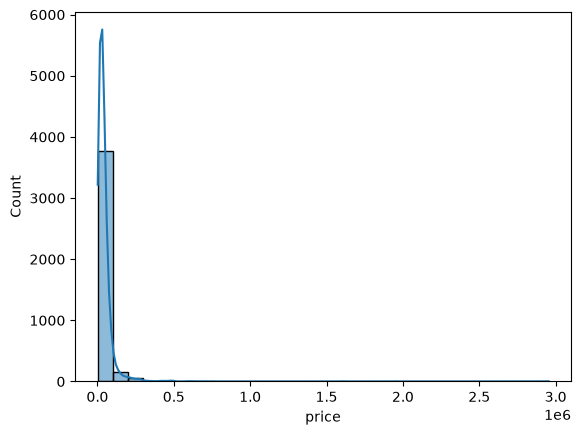

In [881]:
sns.histplot(df_copy['price'] , bins=30 , kde=True)

LEFT SKEWED


<Axes: xlabel='milage', ylabel='Count'>

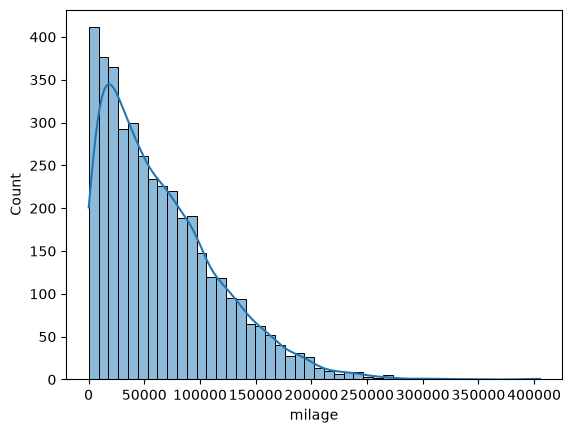

In [882]:
sns.histplot(df_copy['milage'] , kde=True)

RIGHT SKEWED

Drwaing Scatter Plot to check the relationship between price and other numerical data

<Axes: xlabel='milage', ylabel='price'>

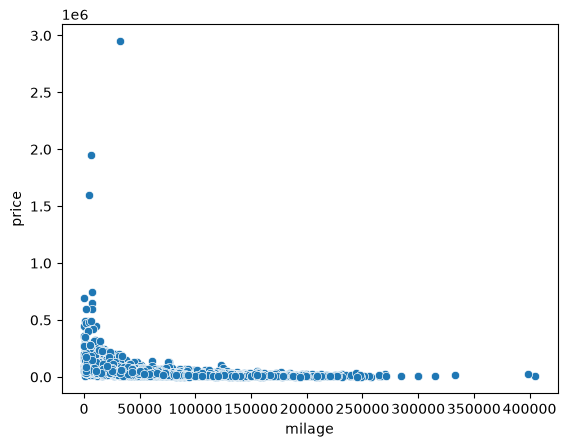

In [883]:
sns.scatterplot(y = df_copy['price'] , x = df_copy['milage'])

Negative..

<Axes: xlabel='model_year', ylabel='price'>

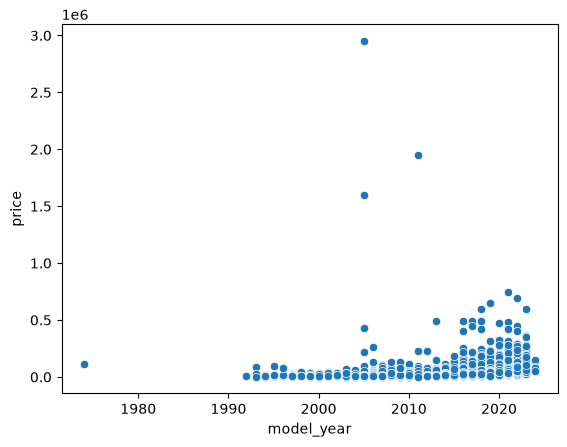

In [884]:
sns.scatterplot(y = df_copy['price'] , x = df_copy['model_year'])

Positive..

<Axes: >

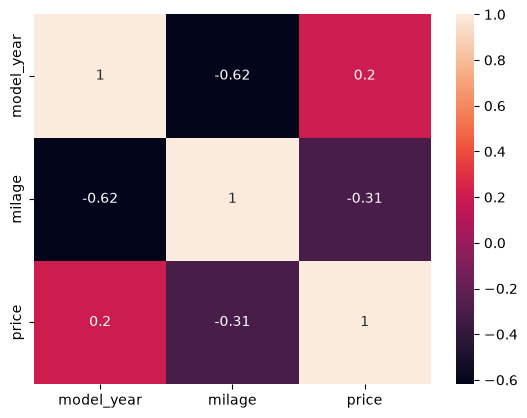

In [885]:
sns.heatmap(data=df_copy.corr(numeric_only=True) , annot=True)

<Axes: ylabel='brand'>

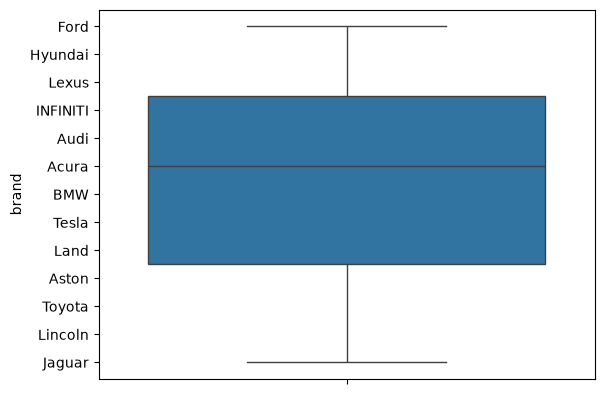

In [886]:
sns.boxplot(df['brand'].head(15)) # As there are many brands

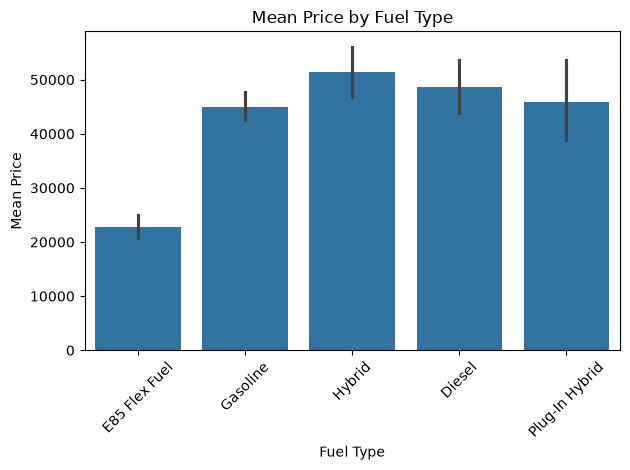

In [887]:
#We need to check that for every fuel_type what is the average price
sns.barplot(
    data=df_copy,
    x='fuel_type',
    y='price',
    estimator='mean'
)

plt.xlabel('Fuel Type')
plt.ylabel('Mean Price')
plt.title('Mean Price by Fuel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

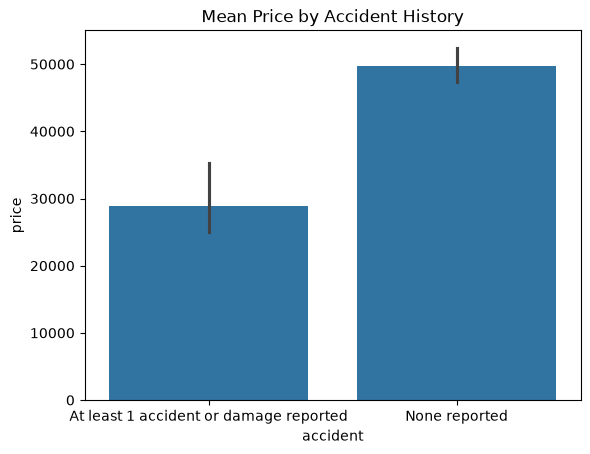

In [888]:
sns.barplot(data=df_copy , x = 'accident' , y = 'price' , estimator='mean')
plt.title('Mean Price by Accident History')
plt.show()

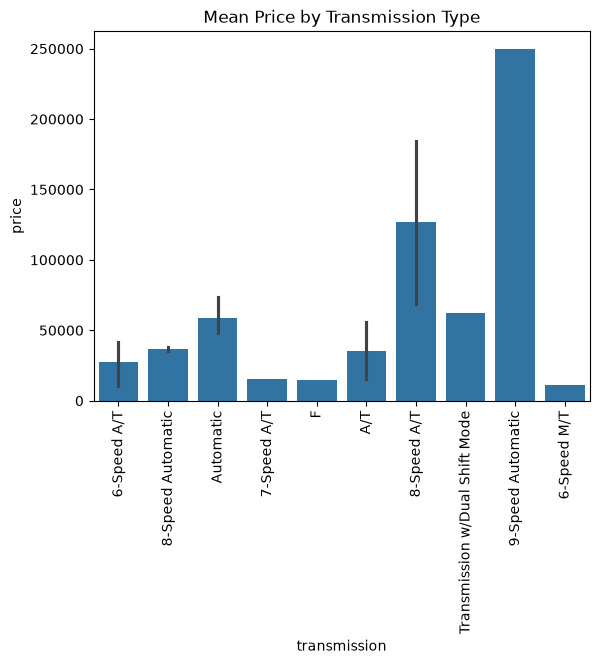

In [889]:
sns.barplot(data=df_copy.head(20) , x = 'transmission' , y = 'price' , estimator='mean')
plt.title('Mean Price by Transmission Type')
plt.xticks(rotation = 90)
plt.show()

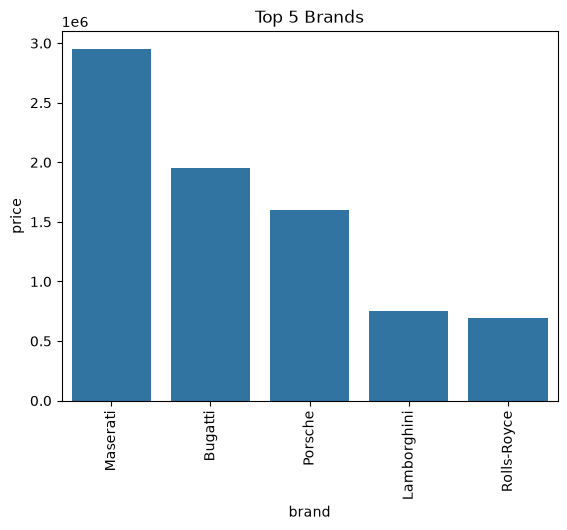

In [890]:
sns.barplot(data=df_copy.sort_values(by='price' , ascending=False).head(5) , x = 'brand' , y = 'price' , estimator='median')
plt.title('Top 5 Brands')
plt.xticks(rotation = 90)
plt.show()

# Feature Selection & Engg.
- In this step we'll decide which features should actually be used for the Linear Regression model.
- Extract meaningful information from various columns such as `Age` from `model_year` etc..

In [891]:
#Check all the columns
df_copy.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [892]:
#Now split the categorical and numerical features.
categorical_cols = df_copy.select_dtypes(include='object').columns


In [893]:
numerical_cols = []

for col in df_copy.columns:
    if col not in categorical_cols:
        numerical_cols.append(col)

In [894]:
#Check the number of unique values from each categorical column
for col in categorical_cols:
    print(col, ":", df_copy[col].nunique())

brand : 57
model : 1898
fuel_type : 5
engine : 1146
transmission : 62
ext_col : 319
int_col : 156
accident : 2
clean_title : 2


In [895]:
#Check some random data
df_copy.sample(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2872,Jeep,Compass Latitude,2014,105000.0,Gasoline,158.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,10950.0
318,Subaru,BRZ Premium,2023,5800.0,Gasoline,228.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,6-Speed M/T,Black,Black,None reported,Yes,29990.0
3417,Porsche,Taycan Base,2021,6900.0,Gasoline,375.0HP Electric Motor Electric Fuel System,2-Speed A/T,White,Beige,None reported,Yes,79999.0
2128,Chevrolet,Avalanche 1500 LT,2007,244000.0,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Gray,Gray,None reported,Yes,16900.0
867,BMW,X5 eDrive xDrive40e,2018,45090.0,Plug-In Hybrid,313.0HP 2.0L 4 Cylinder Engine Plug-In Electri...,8-Speed A/T,Gray,Black,At least 1 accident or damage reported,Yes,30750.0
187,Audi,SQ5 3.0T Premium Plus,2016,60000.0,Gasoline,354.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,At least 1 accident or damage reported,Yes,24700.0
1512,BMW,M5 Base,2006,106000.0,Gasoline,500.0HP 5.0L 10 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,19500.0
2190,Ford,F-350 Lariat Crew Cab Super Duty DRW,2005,176691.0,Diesel,325.0HP 6.0L 8 Cylinder Engine Diesel Fuel,A/T,White,Beige,At least 1 accident or damage reported,Yes,13000.0
2935,MINI,Cooper S Base,2007,45000.0,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,6-Speed M/T,Yellow,Black,None reported,Yes,7900.0
368,BMW,M235 i,2014,125450.0,Gasoline,320.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Blue,Black,None reported,Yes,17200.0


## My Observations:
- We can extract `engine_capacity` , `engine_power` and `engine_type` from `engine` column.
- We can convert `Transmission` column to `Automatic` and `Manual`.
- We can calculate `Age` from `model_year` as it will bw more useful.

In [896]:
# Let's first extract age from model_year. We already know the range i.e. 1974 - 2014

df_copy['age'] = df_copy['model_year'].apply(lambda x: 2015 - x)

In [897]:
#Verifying.... Now we can drop model_year
df_copy.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,2
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,-6
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,-7
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,-6


In [898]:
#Now extract various features from engine..

def extract_litre(x):
    try:
        x = x.lower()
        value = x.split('l')[0].split()[-1]
        return float(value)
    except:
        return None

df_copy['engine_capacity'] = df_copy['engine'].apply(extract_litre).astype(float)


In [899]:
def extract_power(x):
    try:
        value = x.split('HP')[0].split()[-1]
        return float(value)
    except:
        return None

df_copy['engine_power'] = df_copy['engine'].apply(extract_power).astype(float)


In [900]:
#Verifying...
df_copy.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,age,engine_capacity,engine_power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,2,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,-6,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Unknown,54598.0,-7,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,0,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Unknown,34999.0,-6,2.0,NaN


In [901]:
#check null values in those new columns
df_copy[['engine_power' , 'engine_capacity']].isna().sum()

# There are null values because we have converted missing values to unknown

engine_power       808
engine_capacity    220
dtype: int64

In [902]:
#Filling the null values with the median
df_copy['engine_power'] = df_copy['engine_power'].fillna(df_copy['engine_power'].median())
df_copy['engine_capacity'] = df_copy['engine_capacity'].fillna(df_copy['engine_capacity'].median())

In [903]:
#Now converting the Transmission Column
df_copy['transmission'].unique()

<StringArray>
[                                                     '6-Speed A/T',
                                                '8-Speed Automatic',
                                                        'Automatic',
                                                      '7-Speed A/T',
                                                                'F',
                                                              'A/T',
                                                      '8-Speed A/T',
                                   'Transmission w/Dual Shift Mode',
                                                '9-Speed Automatic',
                                                      '6-Speed M/T',
                                                     '10-Speed A/T',
                                                      '9-Speed A/T',
                                                      '5-Speed A/T',
                                                      '1-Speed A/T',
                    

In [904]:
#Function for Extracting Automatic & Manual. I will convert the Ambiguous values to Unknown
def extract_trans(x):
    x = x.lower()

    if 'manual' in x or 'm/t' in x or ' mt' in x:
        return 'Manual'

    elif ('automatic' in x or 
          'a/t' in x or 
          'cvt' in x or 
          'variable' in x or 
          'dct' in x or 
          'dual-clutch' in x):
        return 'Automatic'

    else:
        return 'Unknown'


df_copy['transmission_type'] = df_copy['transmission'].apply(extract_trans)

Now we'll drop some data which i think is not useful like `model_year` because i have already extracted `age`.
I can also drop `engine` and `transmission` because extracted important things.
I'll drop `model`,`ext_col` ,`int_col` because they have many unique values in themselves and has no much relevance

In [905]:
#Again creating a copy so that my real cleaned data won't get affected by dropping columns
cleaned_data = df_copy.copy()

In [907]:
cleaned_data = cleaned_data.drop(columns=['engine', 'model_year', 'transmission'  , 'model', 'ext_col', 'int_col'])

In [908]:
cleaned_data.head()

,brand,milage,fuel_type,accident,clean_title,price,age,engine_capacity,engine_power,transmission_type
0,Ford,51000.0,E85 Flex Fuel,At least 1 accident or damage reported,Yes,10300.0,2,3.7,300.0,Automatic
1,Hyundai,34742.0,Gasoline,At least 1 accident or damage reported,Yes,38005.0,-6,3.8,310.0,Automatic
2,Lexus,22372.0,Gasoline,None reported,Unknown,54598.0,-7,3.5,310.0,Automatic
3,INFINITI,88900.0,Hybrid,None reported,Yes,15500.0,0,3.5,354.0,Automatic
4,Audi,9835.0,Gasoline,None reported,Unknown,34999.0,-6,2.0,310.0,Automatic


Now we'll encode the categorical data using one hot encoding.
Our Categorical Data now are: brand,fuel_type,transmission_type,accident,clean_title

In [909]:
#One hot Encoding
cleaned_data = pd.get_dummies(cleaned_data , columns=['brand' , 'fuel_type' , 'transmission_type' , 'accident' ,'clean_title'] , drop_first=True , dtype=int)

In [910]:
cleaned_data.head()

,milage,price,age,engine_capacity,engine_power,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,...,brand_Volvo,brand_smart,fuel_type_E85 Flex Fuel,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,transmission_type_Manual,transmission_type_Unknown,accident_None reported,clean_title_Yes
0,51000.0,10300.0,2,3.7,300.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,34742.0,38005.0,-6,3.8,310.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,22372.0,54598.0,-7,3.5,310.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,88900.0,15500.0,0,3.5,354.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1
4,9835.0,34999.0,-6,2.0,310.0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0


In [911]:
cleaned_data.isna().sum()

milage                       0
price                        0
age                          0
engine_capacity              0
engine_power                 0
                            ..
fuel_type_Plug-In Hybrid     0
transmission_type_Manual     0
transmission_type_Unknown    0
accident_None reported       0
clean_title_Yes              0
Length: 69, dtype: int64

In [912]:
#Now splitting the input parameters and output parameters
X = cleaned_data.drop(columns=['price'])
y = cleaned_data['price']

In [913]:
#Now splitting the data for training and testing using train-test-split from skicit learn. 80% training data and 20% testing data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [914]:
#Importing and creating the Linear Regression Model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [915]:
#Fitting the data
model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](68,)","[ -0.2 ,-2037.99, 9429.81,..., 2670.86, 4817.38, -424.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](68,)","['milage','age','engine_capacity',...,'transmission_type_Unknown', 'accident_None reported','clean_title_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.856e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,68
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(50)


In [916]:
y_pred = model.predict(X_test)

In [917]:
model.coef_

array([-2.01235671e-01, -2.03799442e+03,  9.42980847e+03,  1.29591313e+01,
       -1.19718137e+04,  2.58873530e+02, -1.28155431e+04, -1.33991300e+04,
        5.19082618e+04,  1.96450856e-10, -2.15272408e+04, -1.69069199e+04,
       -2.78612434e+04, -2.64642457e+04, -2.39262048e+04,  7.73067883e+03,
        1.90295644e+05, -2.16587400e+04, -2.66768477e+04, -2.55290430e+04,
       -9.76354650e+03, -6.02115230e+03, -2.65968517e+04, -2.94799689e+04,
       -2.01503960e+04, -2.16118699e+04,  6.13139995e+02, -2.66369898e+04,
        2.14759491e+05, -4.99923095e+03, -1.64020417e+04, -2.00070812e+04,
        1.47965922e+03, -8.04286723e+02, -1.02008566e+04, -1.27619366e+03,
       -5.14788531e+02, -1.88110427e+04,  1.75440497e+02, -3.63972533e+03,
        6.06565251e+02, -5.79594979e+02, -2.12705182e+04,  3.79284297e+02,
        5.55666722e+02, -5.06598378e+03,  2.79605677e+04, -4.03621975e+04,
        2.05348802e+04,  1.14476723e+04,  8.10993008e+02,  7.30171298e+03,
        1.15049925e+04, -

In [918]:
model.intercept_

np.float64(28556.387179868307)

In [919]:
y_pred

array([ 3.91624582e+04, -7.09290928e+02,  4.22550336e+04,  6.22125425e+04,
        6.57642050e+04,  4.01481843e+04,  4.67242286e+04,  7.18867534e+04,
        1.94905722e+04,  5.32434340e+03,  2.99512531e+04,  2.31978557e+04,
        3.60371537e+04,  6.55911824e+04,  4.36738108e+04,  2.90475523e+04,
        5.41817022e+04,  8.54213210e+04,  8.20629457e+03,  5.50728726e+04,
        2.14323926e+04,  3.65241728e+04,  8.19054965e+04,  7.15100043e+04,
        2.90008937e+04,  1.03653465e+04,  8.22455495e+04,  1.90000475e+04,
        1.49363830e+04,  4.02669765e+04,  5.28366613e+04,  6.12039825e+04,
        1.83215426e+04,  3.29083553e+04,  1.34083106e+04, -3.36444798e+03,
       -1.55823968e+04,  5.00477566e+04, -6.74190147e+03,  1.96394761e+04,
        1.58587234e+04,  4.87225230e+04,  1.06072724e+05,  4.46298270e+04,
        7.02320108e+04,  4.39345595e+04,  4.09049294e+04,  5.34436630e+04,
        4.31622611e+04,  1.54623268e+04,  3.59574787e+04,  1.80840111e+04,
        5.40665158e+04, -

In [920]:
y_test

2580    28000.0
3660     5900.0
897     41000.0
2091    40250.0
1044    77999.0
         ...   
283     54000.0
712     75000.0
274     63000.0
2279    49900.0
621     28000.0
Name: price, Length: 802, dtype: float64

In [921]:
# import mse, mae, r2_score from sklearn.metrics to evaluate the model performance

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate the metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [922]:
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 18791821929.562847
Mean Absolute Error (MAE): 25092.23773305423
R-squared (R2): 0.08061564079821071


In [923]:
#Checking overfitting and underfitting
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.5314529008904476
Testing R²: 0.08061564079821071


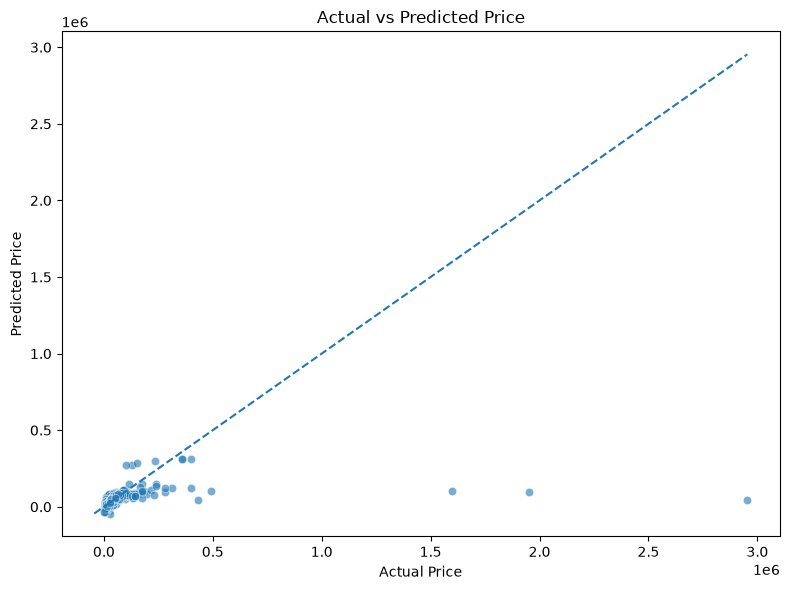

In [924]:


# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.tight_layout()
plt.show()

# Improvision
- Since the errors are so high and r2 score is so low, we need to improve the model.
- I'll try to re-train the model by adding some dropped columns as `model` , `int_col`  and `ext_col` as they can be useful.

In [927]:
cleaned_data_new = df_copy.copy()

In [928]:
cleaned_data_new.drop(columns=['engine', 'model_year', 'transmission'] , inplace = True)

In [929]:
cleaned_data_new = pd.get_dummies(cleaned_data_new , columns=['brand' , 'fuel_type' , 'transmission_type' , 'accident' ,'clean_title','model' , 'int_col' , 'ext_col'] , drop_first=True , dtype=int)

In [930]:
X_new = cleaned_data_new.drop(columns = 'price')
y_new = cleaned_data_new['price']

In [936]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.20)

In [937]:
model2 = LinearRegression()
model2.fit(X_train_new , y_train_new)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](68,)","[ -0.29,-1104.45,10794.86,..., 6199.87, 983.88, 453.54]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](68,)","['milage','age','engine_capacity',...,'transmission_type_Unknown', 'accident_None reported','clean_title_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,68
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(51)


In [938]:
y_pred_new = model2.predict(X_test_new)
y_pred_new

array([ 2.16819301e+04,  3.40996329e+04,  2.24956017e+04,  5.00364914e+04,
        3.24712213e+04,  3.83493971e+04,  2.37375818e+04,  1.85930504e+03,
        9.20215340e+04,  2.51530280e+05, -3.40722522e+04,  8.33852794e+04,
        6.92459303e+04,  3.79201704e+04,  9.44280008e+03,  8.17862097e+04,
        4.58663578e+04,  6.39135730e+04, -1.60366603e+04,  5.84552203e+04,
        1.86252651e+04,  6.05466850e+04,  6.29032393e+04,  4.09229999e+04,
        5.03384626e+04,  5.43579011e+04,  4.15974362e+04,  7.74231230e+04,
        5.49876684e+04,  4.11660261e+04,  3.61343117e+04,  2.77563668e+04,
       -3.04064724e+04,  2.44779162e+04,  1.01401331e+05,  6.45128229e+04,
        3.74322783e+04,  6.00303156e+04,  3.92131577e+04,  4.92606947e+04,
        8.53958964e+04,  3.23406793e+04,  5.60048537e+04,  7.78680880e+04,
        6.82153430e+03,  2.55706631e+04,  8.67912859e+04, -1.80095883e+04,
        1.07528040e+05,  4.02323766e+04,  2.85530820e+04,  1.38538486e+04,
        4.27972663e+04,  

In [939]:
y_test_new

3421    33500.0
1135    24995.0
2178    25500.0
1968    49500.0
3310    28000.0
         ...   
1549    36999.0
737     17995.0
1652    10750.0
1735    65000.0
2596    41500.0
Name: price, Length: 802, dtype: float64

In [940]:
mse_new = mean_squared_error(y_test_new, y_pred_new)
mae_new = mean_absolute_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print("Improved Mean Squared Error (MSE):", mse_new)
print("Improved Mean Absolute Error (MAE):", mae_new)
print("Improved R-squared (R2):", r2_new)

Improved Mean Squared Error (MSE): 1215713084.618046
Improved Mean Absolute Error (MAE): 18372.954938852323
Improved R-squared (R2): 0.37915213893664423


In [942]:
#Checking overfitting and underfitting
train_predictions_new = model.predict(X_train_new)
test_predictions_new = model.predict(X_test_new)
train_r2_new = r2_score(y_train_new, train_predictions_new)
test_r2_new = r2_score(y_test_new, test_predictions_new)

print("Improved Training R²:", train_r2_new)
print("Improved Testing R²:", test_r2_new)

Improved Training R²: 0.21960200838433697
Improved Testing R²: 0.45083014012959455


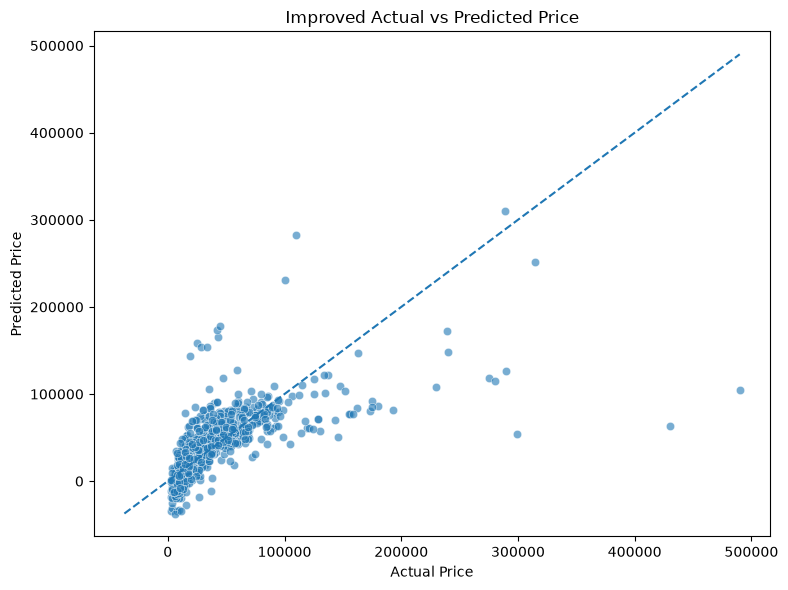

In [941]:


# Actual vs Predicted plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test_new,
    y=y_pred_new,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test_new.min(), y_pred_new.min())
max_val = max(y_test_new.max(), y_pred_new.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Improved Actual vs Predicted Price')
plt.tight_layout()
plt.show()